In [6]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# folder path
folder_path = "NBA Shot Data"

# load and sort all csv files
csv_files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))

# read and combine into single df
df = pd.concat(
    [pd.read_csv(file) for file in csv_files],
    ignore_index=True
)

In [7]:
# 1. data preparation (15 years)

df_copy = df.copy()

recent_seasons = [
    '2009-10','2010-11','2011-12','2012-13','2013-14',
    '2014-15','2015-16','2016-17','2017-18','2018-19',
    '2019-20','2020-21','2021-22','2022-23','2023-24'
]

df_recent = df_copy[df_copy['SEASON_2'].isin(recent_seasons)].copy()
df_recent['SHOT_MADE_BINARY'] = df_recent['SHOT_MADE'].astype(int)

print("Total rows:", len(df_recent))
print("Players:", df_recent['PLAYER_NAME'].nunique())

Total rows: 3053916
Players: 1753


In [8]:
# 2. manual AR(1) functions

def fit_ar1_manual(series):
    Y = series[1:]
    X = series[:-1]
    
    X_matrix = np.column_stack((np.ones(len(X)), X))
    beta = np.linalg.inv(X_matrix.T @ X_matrix) @ (X_matrix.T @ Y)
    
    return beta[0], beta[1]

def predict_ar1(series, beta0, beta1):
    return beta0 + beta1 * series[:-1]

In [9]:
# 3. train/test split function

def train_test_split_series(series, split=0.8):
    n = len(series)
    split_idx = int(n * split)
    return series[:split_idx], series[split_idx:]

In [10]:
# 4. loop through players

results = []
all_residuals = []

players = df_recent['PLAYER_NAME'].unique()

for player in players:
    player_df = df_recent[df_recent['PLAYER_NAME'] == player].sort_values('GAME_DATE')
    
    series = player_df['SHOT_MADE_BINARY'].values
    
    if len(series) < 50:   # ensure stability
        continue
    
    train, test = train_test_split_series(series, 0.8)
    
    if len(train) < 2 or len(test) < 2:
        continue
    
    # Fit model on training data
    beta0, beta1 = fit_ar1_manual(train)
    
    # Predictions on test set
    test_preds = beta0 + beta1 * test[:-1]
    test_actual = test[1:]
    
    # Metrics
    mse = np.mean((test_actual - test_preds)**2)
    
    # Convert to classification (threshold = 0.5)
    pred_binary = (test_preds >= 0.5).astype(int)
    accuracy = np.mean(pred_binary == test_actual)
    
    residuals = test_actual - test_preds
    all_residuals.extend(residuals)
    
    results.append({
        'PLAYER_NAME': player,
        'TOTAL_SHOTS': len(series),
        'AR1_COEFFICIENT': beta1,
        'MSE': mse,
        'ACCURACY': accuracy
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

In [11]:
# 5. top players table

top_players = results_df.sort_values('AR1_COEFFICIENT', ascending=False).head(10)

print("\nTop 10 Players by AR(1) Coefficient:")
print(top_players)


Top 10 Players by AR(1) Coefficient:
            PLAYER_NAME  TOTAL_SHOTS  AR1_COEFFICIENT       MSE  ACCURACY
393          Tim Thomas          106         0.372674  0.293110  0.476190
1240       Joe Wieskamp           70         0.276316  0.239839  0.538462
1161       Gabriel Deck           81         0.267748  0.220748  0.687500
450    Derrick Caracter           66         0.255385  0.215229  0.692308
353    Hilton Armstrong          174         0.225382  0.248336  0.529412
1177   Vernon Carey Jr.           57         0.225000  0.236534  0.636364
892         Jamel Artis           79         0.212698  0.223958  0.600000
397       Sean Williams           71         0.197613  0.276865  0.428571
1245  Justin Champagnie          160         0.190464  0.221018  0.677419
97       Othyus Jeffers          100         0.186615  0.251658  0.526316


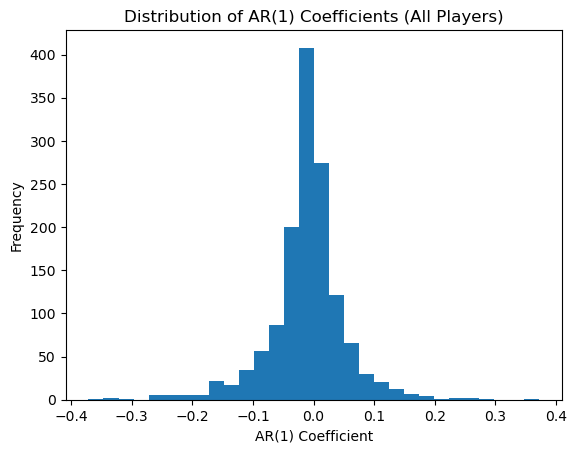

In [12]:
# 6. distribution of AR(1)

plt.figure()
plt.hist(results_df['AR1_COEFFICIENT'], bins=30)
plt.title("Distribution of AR(1) Coefficients (All Players)")
plt.xlabel("AR(1) Coefficient")
plt.ylabel("Frequency")
plt.show()

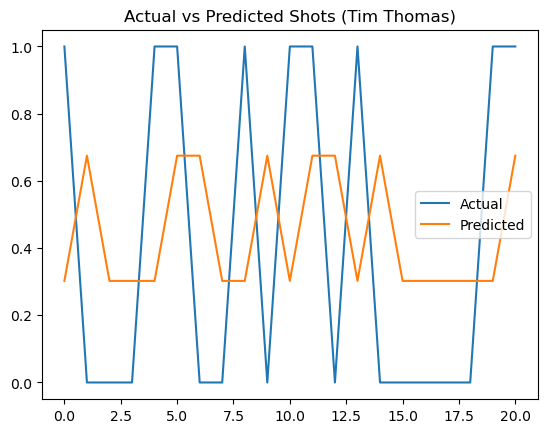

In [13]:
# 7. sample player predictions

sample_player = top_players.iloc[0]['PLAYER_NAME']

player_df = df_recent[df_recent['PLAYER_NAME'] == sample_player].sort_values('GAME_DATE')
series = player_df['SHOT_MADE_BINARY'].values

train, test = train_test_split_series(series, 0.8)

beta0, beta1 = fit_ar1_manual(train)

preds = beta0 + beta1 * test[:-1]
actual = test[1:]

plt.figure()
plt.plot(actual[:100], label='Actual')
plt.plot(preds[:100], label='Predicted')
plt.title(f"Actual vs Predicted Shots ({sample_player})")
plt.legend()
plt.show()

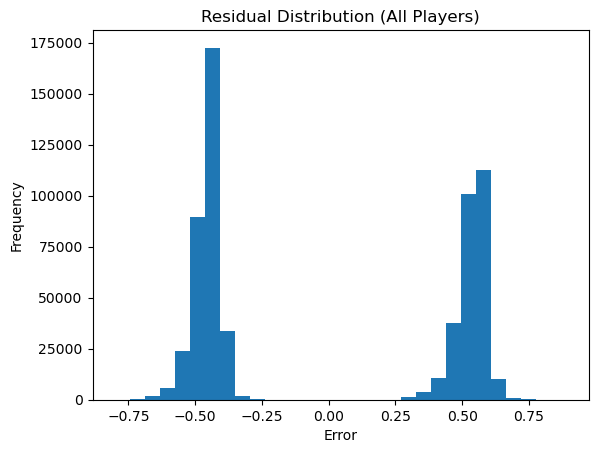

In [14]:
# 8. residual distributions

plt.figure()
plt.hist(all_residuals, bins=30)
plt.title("Residual Distribution (All Players)")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [15]:
# 9. summary metrics
print("\nOverall Model Performance:")
print("Average AR(1):", results_df['AR1_COEFFICIENT'].mean())
print("Average MSE:", results_df['MSE'].mean())
print("Average Accuracy:", results_df['ACCURACY'].mean())


Overall Model Performance:
Average AR(1): -0.011135004804766986
Average MSE: 0.24472201311565364
Average Accuracy: 0.5684605385768716


In [16]:
# testing best AR model

def fit_ar_p(series, p):
    Y = series[p:]
    
    X = []
    for i in range(p):
        X.append(series[p - i - 1: -i - 1])
    X = np.column_stack(X)
    X = np.column_stack((np.ones(len(X)), X))
    beta = np.linalg.inv(X.T @ X) @ (X.T @ Y)
    return beta
    
def predict_ar_p(series, beta, p):
    preds = []
    
    for t in range(p, len(series)):
        lags = series[t-p:t][::-1]
        x = np.insert(lags, 0, 1)
        preds.append(x @ beta)
    
    return np.array(preds)


# model comparison

model_results = []

for player in df_recent['PLAYER_NAME'].unique():
    player_df = df_recent[df_recent['PLAYER_NAME'] == player].sort_values('GAME_DATE')
    series = player_df['SHOT_MADE_BINARY'].values
    
    if len(series) < 50:
        continue
    
    # train/test split
    split_idx = int(len(series) * 0.8)
    train = series[:split_idx]
    test = series[split_idx:]
    
    for p in [1, 2, 3]:
        if len(train) <= p or len(test) <= p:
            continue
        
        beta = fit_ar_p(train, p)
        
        preds = predict_ar_p(test, beta, p)
        actual = test[p:]
        
        mse = np.mean((actual - preds)**2)

        n = len(actual)
        k = p + 1
        aic = n * np.log(mse) + 2 * k
        
        model_results.append({
            'PLAYER_NAME': player,
            'MODEL': f'AR({p})',
            'MSE': mse,
            'AIC': aic
        })

model_df = pd.DataFrame(model_results)

# best model per player
best_models = model_df.loc[model_df.groupby('PLAYER_NAME')['MSE'].idxmin()]

# summary
print("Best model counts:")
print(best_models['MODEL'].value_counts())

Best model counts:
MODEL
AR(1)    669
AR(3)    394
AR(2)    330
Name: count, dtype: int64
